In [1]:
!pip install transformers datasets torch accelerate

### 1. Load dataset

In [2]:
from datasets import load_dataset

dataset = load_dataset("imdb")

train_data = dataset["train"].select(range(200))
test_data = dataset["test"].select(range(100))

### 2. Tokenizer

In [3]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

### 3. Tokenize function

In [4]:
def tokenize(example):
    return tokenizer(example["text"], padding="max_length", truncation=True)

### 4. APPLY TOKENIZATION

In [5]:
train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

### 5. Rename label

In [6]:
train_data = train_data.rename_column("label", "labels")
test_data = test_data.rename_column("label", "labels")

### 6. Set format

In [7]:
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

### 7. Model

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 8. Trainer

In [9]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=1
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data
)

### 9. Train

In [10]:
trainer.train()

C:\Users\Dell\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=25, training_loss=0.10434884071350098, metrics={'train_runtime': 869.8381, 'train_samples_per_second': 0.23, 'train_steps_per_second': 0.029, 'total_flos': 26493479731200.0, 'train_loss': 0.10434884071350098, 'epoch': 1.0})

### 10. Evaluate

In [11]:
trainer.evaluate()

C:\Users\Dell\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Step
No log,0.005878,25


{'eval_loss': 0.005878482945263386}

### 11.define pipeline

In [12]:
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model=model,
    tokenizer=tokenizer
)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


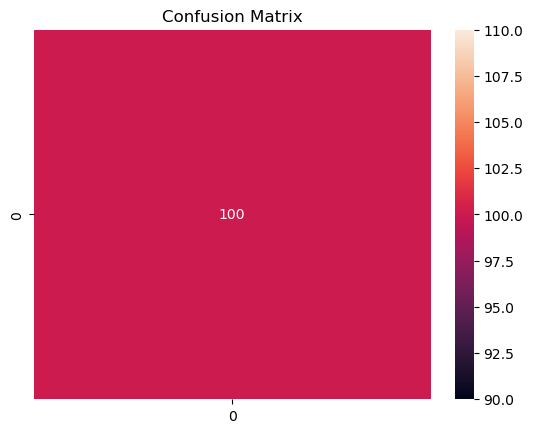

In [13]:
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dataset = load_dataset("imdb", split="test[:100]")

predictions = []
true_labels = []

for sample in dataset:
    text = sample["text"]
    label = sample["label"]

    result = classifier(text, truncation=True)[0]
    pred = 1 if result["label"] == "POSITIVE" else 0

    predictions.append(pred)
    true_labels.append(label)

cm = confusion_matrix(true_labels, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()